<a href="https://colab.research.google.com/github/tezendrax/DDoS-Attack-Detection-using-Machine-Learning/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from scipy.io import arff

# Load the ARFF file
data, meta = arff.loadarff('/content/final-dataset (1).arff')

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Show basic information
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (2160668, 28)

First 5 rows:
   SRC_ADD  DES_ADD    PKT_ID  FROM_NODE  TO_NODE PKT_TYPE  PKT_SIZE  \
0     3.00    24.30  389693.0       21.0     23.0   b'tcp'    1540.0   
1    15.00    24.15  201196.0       23.0     24.0   b'tcp'    1540.0   
2    24.15    15.00   61905.0       23.0     22.0   b'ack'      55.0   
3    24.90     9.00  443135.0       23.0     21.0   b'ack'      55.0   
4    24.80     8.00  157335.0       23.0     21.0   b'ack'      55.0   

        FLAGS   FID  SEQ_NUMBER  ...    PKT_RATE  BYTE_RATE PKT_AVG_SIZE  \
0  b'-------'   4.0     11339.0  ...  328.240918   505490.0       1540.0   
1  b'-------'  16.0      6274.0  ...  328.205808   505437.0       1540.0   
2  b'-------'  16.0      1930.0  ...  328.206042    18051.3         55.0   
3  b'-------'  10.0     12670.0  ...  328.064183    18043.5         55.0   
4  b'-------'   9.0      4901.0  ...  328.113525    18046.2         55.0   

  UTILIZATION  PKT_DELAY  PKT_SEND_TIME  PKT_RESEVED_TIME  FIRS

In [3]:
# Take a random sample of 50,000 rows
df_sample = df.sample(n=50000, random_state=42)

# Reset index (important for clean data)
df_sample = df_sample.reset_index(drop=True)

# Check new shape
print("New dataset shape:", df_sample.shape)

# See first few rows
df_sample.head()

New dataset shape: (50000, 28)


,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,PKT_CLASS
0,24.11,11.00,13072.0,23.0,22.0,b'ack',55.0,b'-------',12.0,408.0,...,328.522947,18068.8,55.0,0.008446,0.00000,2.441154,2.471163,1.030019,50.046382,b'Normal'
1,2.00,24.20,183804.0,2.0,21.0,b'tcp',1540.0,b'-------',3.0,5742.0,...,328.264040,505526.0,1540.0,0.236321,0.00000,18.518848,18.549218,1.000000,50.018467,b'Normal'
2,15.00,24.15,555513.0,23.0,24.0,b'tcp',1540.0,b'-------',16.0,15511.0,...,328.205808,505437.0,1540.0,0.236337,0.00000,48.238006,48.268376,1.000000,50.030211,b'Normal'
3,1.20,24.43,25407.0,21.0,23.0,b'cbr',1500.0,b'-------',22.0,976.0,...,1016.542930,1524810.0,1500.0,0.130291,0.03540,24.698286,24.733686,1.000000,9.959779,b'UDP-Flood'
4,3.10,24.23,584008.0,23.0,24.0,b'cbr',1000.0,b'-------',24.0,3391.0,...,124.943226,124943.0,1000.0,0.059605,0.00048,52.128000,52.158720,25.000000,75.022720,b'Normal'


In [15]:
selected_columns = [
    'PKT_SIZE',
    'PKT_RATE',
    'BYTE_RATE',
    'NUMBER_OF_PKT',
    'PKT_DELAY_NODE',
    'PKT_TYPE',
    'PKT_CLASS'   # target (VERY IMPORTANT)
]

In [16]:
# Select only important columns
df_selected = df_sample[selected_columns]

# Check shape
print("Selected dataset shape:", df_selected.shape)

# View data
df_selected.head()

Selected dataset shape: (50000, 7)


,PKT_SIZE,PKT_RATE,BYTE_RATE,NUMBER_OF_PKT,PKT_DELAY_NODE,PKT_TYPE,PKT_CLASS
0,55.0,328.522947,18068.8,16103.0,0.00000,b'ack',b'Normal'
1,1540.0,328.264040,505526.0,16091.0,0.00000,b'tcp',b'Normal'
2,1540.0,328.205808,505437.0,16092.0,0.00000,b'tcp',b'Normal'
3,1500.0,1016.542930,1524810.0,9108.0,0.00204,b'cbr',b'UDP-Flood'
4,1000.0,124.943226,124943.0,6250.0,0.00024,b'cbr',b'Normal'


In [17]:
# Select only important columns (with copy)
df_selected = df_sample[selected_columns].copy()

# Convert byte strings to normal strings
for col in df_selected.columns:
    if df_selected[col].dtype == 'object':
        df_selected.loc[:, col] = df_selected[col].apply(
            lambda x: x.decode('utf-8') if isinstance(x, bytes) else x
        )

In [18]:
df_selected.head()

,PKT_SIZE,PKT_RATE,BYTE_RATE,NUMBER_OF_PKT,PKT_DELAY_NODE,PKT_TYPE,PKT_CLASS
0,55.0,328.522947,18068.8,16103.0,0.00000,ack,Normal
1,1540.0,328.264040,505526.0,16091.0,0.00000,tcp,Normal
2,1540.0,328.205808,505437.0,16092.0,0.00000,tcp,Normal
3,1500.0,1016.542930,1524810.0,9108.0,0.00204,cbr,UDP-Flood
4,1000.0,124.943226,124943.0,6250.0,0.00024,cbr,Normal


In [46]:
# Create binary target column
df_selected['TARGET'] = df_selected['PKT_CLASS'].apply(lambda x: 0 if x == 'Normal' else 1)

# Check distribution
print(df_selected['TARGET'].value_counts())

# View updated data
df_selected.head()


#   We converted the multiclass target into a binary classification problem by
#   labeling normal traffic as 0 and attack traffic as 1 to simplify the
#   detection task.



TARGET
0    44827
1     5173
Name: count, dtype: int64


,PKT_SIZE,PKT_RATE,BYTE_RATE,NUMBER_OF_PKT,PKT_DELAY_NODE,PKT_TYPE,PKT_CLASS,TARGET
0,55.0,328.522947,18068.8,16103.0,0.00000,ack,Normal,0
1,1540.0,328.264040,505526.0,16091.0,0.00000,tcp,Normal,0
2,1540.0,328.205808,505437.0,16092.0,0.00000,tcp,Normal,0
3,1500.0,1016.542930,1524810.0,9108.0,0.00204,cbr,UDP-Flood,1
4,1000.0,124.943226,124943.0,6250.0,0.00024,cbr,Normal,0


In [27]:
from sklearn.preprocessing import LabelEncoder

# Step 5.1: Separate features and target
X = df_selected.drop(columns=['PKT_CLASS', 'TARGET'])
y = df_selected['TARGET']

# Step 5.2: Encode categorical column (PKT_TYPE)
encoder = LabelEncoder()
X['PKT_TYPE'] = encoder.fit_transform(X['PKT_TYPE'])

# Check result
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


#   We separated the input features and target variable, and encoded categorical
#   features like packet type into numerical values to make them compatible
#   with machine learning models.
# tcp → 0
# ack → 1
# cbr → 2

X shape: (50000, 6)
y shape: (50000,)


,PKT_SIZE,PKT_RATE,BYTE_RATE,NUMBER_OF_PKT,PKT_DELAY_NODE,PKT_TYPE
0,55.0,328.522947,18068.8,16103.0,0.00000,0
1,1540.0,328.264040,505526.0,16091.0,0.00000,3
2,1540.0,328.205808,505437.0,16092.0,0.00000,3
3,1500.0,1016.542930,1524810.0,9108.0,0.00204,1
4,1000.0,124.943226,124943.0,6250.0,0.00024,1


In [28]:
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'ack': np.int64(0), 'cbr': np.int64(1), 'ping': np.int64(2), 'tcp': np.int64(3)}


In [29]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000, 6)
X_test: (10000, 6)
y_train: (40000,)
y_test: (10000,)


In [30]:
from sklearn.preprocessing import StandardScaler

# 7) Create scaler
scaler = StandardScaler()

# Fit on training data ONLY and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Check shape
print("Scaled X_train:", X_train_scaled.shape)
print("Scaled X_test:", X_test_scaled.shape)

Scaled X_train: (40000, 6)
Scaled X_test: (10000, 6)


In [32]:
# 8) Train Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# -------------------------
# Model 1: Logistic Regression
# -------------------------
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# -------------------------
# Model 2: Random Forest
# -------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)   # NOTE: RF doesn't need scaling

# -------------------------
# Model 3: Support Vector Machine (SVM)
# -------------------------
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

print("All models trained successfully ")

All models trained successfully 


In [36]:
# =========================
# STEP 9: Evaluate Models
# =========================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# -------------------------
# Predictions
# -------------------------
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test_scaled)

# -------------------------
# Logistic Regression Results
# -------------------------
print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

# -------------------------
# Random Forest Results
# -------------------------
print("\n===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# -------------------------
# SVM Results
# -------------------------
print("\n===== SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

===== Logistic Regression =====
Accuracy : 0.9831
Precision: 1.0
Recall   : 0.8367149758454107
F1 Score : 0.9110994213571805
Confusion Matrix:
 [[8965    0]
 [ 169  866]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      8965
           1       1.00      0.84      0.91      1035

    accuracy                           0.98     10000
   macro avg       0.99      0.92      0.95     10000
weighted avg       0.98      0.98      0.98     10000


===== Random Forest =====
Accuracy : 0.9865
Precision: 0.993421052631579
Recall   : 0.8753623188405797
F1 Score : 0.9306625577812019
Confusion Matrix:
 [[8959    6]
 [ 129  906]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      8965
           1       0.99      0.88      0.93      1035

    accuracy                           0.99     10000
   macro avg       0.99      0.94      0.96     10000
we

In [37]:
# =========================
# STEP 10: Compare Models and Final Conclusion
# =========================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.9831   1.000000  0.836715  0.911099
1        Random Forest    0.9865   0.993421  0.875362  0.930663
2                  SVM    0.9844   0.971061  0.875362  0.920732


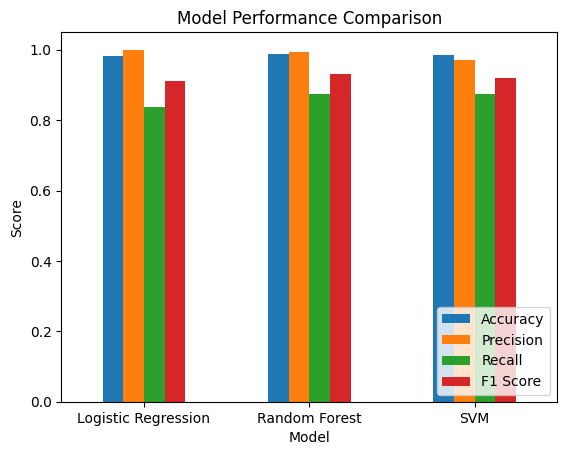

In [38]:
# =========================
# GRAPH 1: Model Comparison
# =========================

import matplotlib.pyplot as plt

# Plot bar chart
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

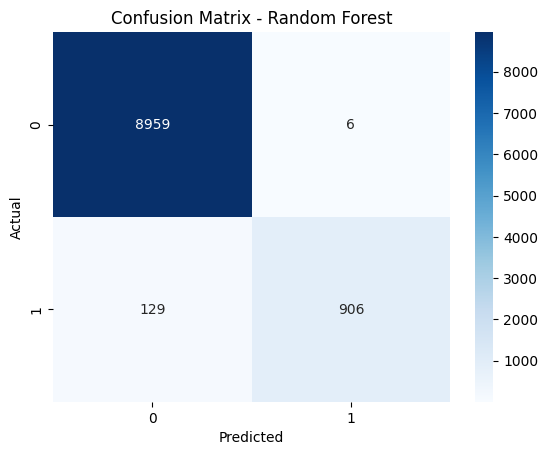

In [39]:
# =========================
# GRAPH 2: Confusion Matrix
# =========================

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Use best model prediction (example: Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

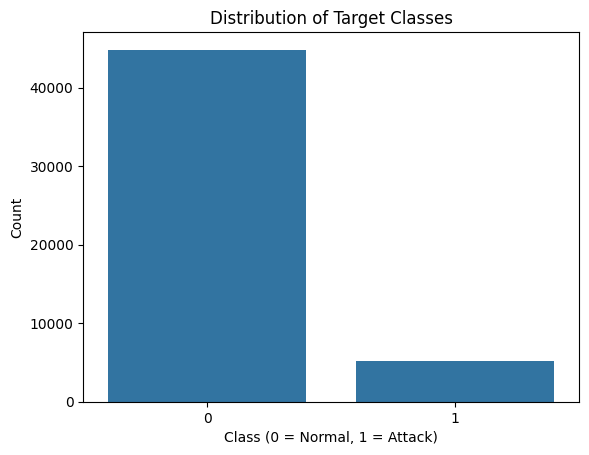

In [40]:
# =========================
# GRAPH 3: Target Distribution
# =========================

import seaborn as sns

sns.countplot(x=y)
plt.title("Distribution of Target Classes")
plt.xlabel("Class (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()